# GPT Image 2로 텍스트에서 이미지 생성하기

GPT Image 2는 자연어 prompt를 입력받아 새 이미지를 생성하거나 기존 이미지를 편집하는 OpenAI의 이미지 모델이다. **Prompt**는 모델에 원하는 장면과 조건을 전달하는 입력 문장이다. 그림 도구를 직접 다루지 않아도 대상, 행동, 구도, 조명과 표현 방식을 prompt로 지정할 수 있어 교육 자료, 시안과 콘텐츠 제작에 활용할 수 있다.

이 실습에서는 **관리형 API**를 사용한다. 관리형 API는 로컬 PC에 모델 가중치를 내려받거나 GPU를 준비하지 않아도 되지만, 요청이 OpenAI 서버에서 처리되므로 API key, 네트워크, 사용 권한과 비용이 필요하다. Stable Diffusion처럼 로컬에서 실행하는 모델은 실행 환경을 직접 관리하는 대신 모델과 추론 설정을 더 세밀하게 통제할 수 있다는 차이가 있다.


## 현재 API와 실습 전 확인 사항

신규 실습은 현재 이미지 생성·편집 모델인 `gpt-image-2`를 사용한다. DALL-E 2와 DALL-E 3은 2026년 5월 12일 API에서 제거됐으므로 역사적 모델로만 다루며, 기존 DALL-E 호출 코드를 새 실습에 사용하지 않는다.

- **API key**: `OPENAI_API_KEY`는 `.env`에 저장하고 코드나 출력에 직접 노출하지 않는다.
- **비용**: 이미지 생성 요청마다 비용이 발생하므로 실행 전에 계정의 사용 한도와 최신 가격을 확인한다.
- **정책**: 실제 인물, 상표, 민감한 소재를 다룰 때는 콘텐츠 정책과 활용 목적을 먼저 확인한다. 생성됐다는 사실만으로 모든 이용 권리가 자동으로 보장된다고 단정하지 않는다.
- **결과 차이**: 같은 prompt를 다시 보내도 세부 표현이 달라질 수 있으므로 한 번의 결과만으로 prompt 품질을 단정하지 않는다.

공식 기준은 [GPT Image 2 모델 문서](https://developers.openai.com/api/docs/models/gpt-image-2), [Image Generation 가이드](https://developers.openai.com/api/docs/guides/image-generation), [API 지원 종료 안내](https://developers.openai.com/api/docs/deprecations)에서 확인할 수 있다.

## GPT Image API 요청 흐름

![GPT Image API의 prompt 입력부터 파일 저장까지의 흐름](https://cdn.jsdelivr.net/gh/goat-skn-ai/image-repo@20132d4eb888d7c341e15c2fb4573d0ecf60c0da/09_multimodal/05_image_generation/04_gpt_image_api_flow.svg)

그림은 왼쪽에서 오른쪽으로 읽는다. 전체 흐름은 다음과 같다.

1. **입력 준비**: `model`에는 사용할 이미지 모델 ID를, `prompt`에는 생성할 장면의 조건을 넣는다.
2. **API 요청**: OpenAI Python SDK의 `client.images.generate()`가 입력을 Image Generation API로 전송한다.
3. **서버 처리**: OpenAI 서버에서 모델이 prompt를 해석하고 이미지 한 장을 생성한다.
4. **응답 수신**: 생성 결과 목록인 `data`의 첫 항목 `data[0]`에서 `b64_json` 문자열을 꺼낸다.
5. **파일 변환**: Base64 문자열을 bytes로 디코딩하고 PNG 파일로 저장한 뒤 노트북에서 표시한다.

**Base64**는 이미지의 이진 데이터를 JSON 응답 안에서 전달할 수 있도록 텍스트로 표현한 형식이다. 화면에 바로 표시할 픽셀 배열이 아니므로 Python에서 먼저 원래 bytes로 되돌려야 한다.

### 공식 Image Generation 가이드에 수록된 예시 이미지

![OpenAI Image Generation 가이드의 생성 결과 예시](https://cdn.openai.com/API/docs/images/mug.png)

이 이미지는 OpenAI Image Generation 가이드의 개요에 수록된 참고 이미지이다. 사용한 prompt와 모델은 페이지에 공개되어 있지 않으며, 아래의 로봇 prompt를 실행한 결과로 볼 수 없다.

이 셀에서는 API가 반환할 수 있는 이미지 형식의 예시로만 확인한다. prompt 조건과 결과의 구체적인 연결은 뒤의 구조화 prompt 공식 예시와 실제 API 실습에서 확인한다. 출처는 [OpenAI Image Generation 가이드](https://developers.openai.com/api/docs/guides/image-generation)이다.

## 패키지 설치

`openai`는 Image Generation API를 호출하고, `python-dotenv`는 상위 폴더의 `.env`를 찾는 데 사용한다. `Pillow`와 `matplotlib`은 저장한 이미지 파일을 열어 나란히 비교할 때 사용한다.

In [1]:
%pip install -q openai python-dotenv pillow matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\playdata2\miniforge3\envs\llm_env\python.exe -m pip install --upgrade pip


## 상위 `.env`에서 API key 불러오기

`find_dotenv(usecwd=True)`는 현재 작업 폴더에서 시작해 상위 폴더로 올라가며 가장 가까운 `.env`를 찾는다. `load_dotenv()`는 파일의 환경변수를 현재 Python process에 불러온다. 그러면 뒤의 `OpenAI()`가 `OPENAI_API_KEY`를 자동으로 읽을 수 있다.

`.env`에는 `OPENAI_API_KEY=...` 형식으로 key가 준비되어 있어야 한다. 파일이 없거나 변수가 설정되지 않으면 뒤의 `OpenAI()` client 생성 단계에서 인증 설정 오류가 발생한다.

In [2]:
import os
from dotenv import find_dotenv, load_dotenv

# usecwd=True는 notebook 파일 위치가 아니라 현재 working directory를 검색 시작점으로 사용한다.
env_path = find_dotenv(usecwd=True)

dotenv_loaded = load_dotenv(env_path)

# bool 값만 확인하므로 key 문자열 자체는 화면에 나타나지 않는다.
api_key_configured = bool(os.getenv("OPENAI_API_KEY"))
print(".env 로드 여부:", dotenv_loaded)
print("OPENAI_API_KEY 설정 여부:", api_key_configured)


.env 로드 여부: True
OPENAI_API_KEY 설정 여부: True


## API client와 비교용 prompt 준비

`OpenAI()`는 앞 셀에서 환경변수로 불러온 `OPENAI_API_KEY`를 사용해 **API client**를 만든다. API client는 인증 정보와 요청 메서드를 묶은 Python 객체이며, 이 단계에서는 아직 유료 이미지 생성 요청을 보내지 않는다. 다음 생성 함수가 이 객체의 `images.generate()` 메서드를 사용한다.

두 prompt는 같은 대상인 ‘책을 읽는 작은 로봇’을 요청한다. 첫 prompt는 대상과 스타일만 간단히 쓰고, 두 번째 prompt는 **대상 → 행동 → 구도 → 조명 → 배경 → 표현 방식** 순서로 조건을 구체화한다. 두 결과를 비교하면 prompt에 명시한 조건이 생성 이미지의 구성에 얼마나 반영됐는지 확인할 수 있다.

In [3]:
from openai import OpenAI

# OpenAI()는 OPENAI_API_KEY 환경변수를 읽어 인증 가능한 client를 만들며, 이 줄 자체는 이미지 생성 요청을 보내지 않는다.
client = OpenAI()
# 모델 ID를 상수로 두면 아래 생성 함수의 모든 요청이 같은 모델을 사용한다.
MODEL_NAME = "gpt-image-2"

simple_prompt = "책을 읽는 작은 로봇의 따뜻한 수채화 일러스트"

structured_prompt = """
대상: 작은 둥근 로봇 한 대
행동: 나무 책상에 앉아 펼친 책을 읽는 모습
구도: 로봇과 책이 모두 보이는 정면 중간 거리, 정사각형 화면
조명: 왼쪽 창문에서 들어오는 부드러운 아침 햇빛
배경: 식물과 책장이 있는 조용한 작은 도서관
표현 방식: 따뜻한 파스텔 색감의 수채화 동화책 일러스트
""".strip()

print("간단한 prompt:", simple_prompt)
print("구조화 prompt:\n", structured_prompt)


간단한 prompt: 책을 읽는 작은 로봇의 따뜻한 수채화 일러스트
구조화 prompt:
 대상: 작은 둥근 로봇 한 대
행동: 나무 책상에 앉아 펼친 책을 읽는 모습
구도: 로봇과 책이 모두 보이는 정면 중간 거리, 정사각형 화면
조명: 왼쪽 창문에서 들어오는 부드러운 아침 햇빛
배경: 식물과 책장이 있는 조용한 작은 도서관
표현 방식: 따뜻한 파스텔 색감의 수채화 동화책 일러스트


## API 응답을 이미지 파일로 저장하는 함수

`client.images.generate()`는 **입력인 `model`과 `prompt`를 API에 보내고 생성 결과 객체를 반환**한다. `model`은 사용할 모델 ID이고, `prompt`는 이미지에 반영할 자연어 조건이다. 이 실습은 `size`와 `quality`를 따로 지정하지 않으므로 GPT Image 2의 기본값인 `auto`가 적용되어 모델이 prompt에 맞는 값을 선택한다.

성공한 응답의 `data`는 생성 결과 목록이며, `data[0].b64_json`은 첫 번째 이미지를 Base64 텍스트로 표현한 값이다. `base64.b64decode()`가 이를 파일에 기록할 수 있는 bytes로 되돌리고, `Path.write_bytes()`가 PNG 파일로 저장한다.

`generate_and_save(prompt, filename)`은 **prompt 입력 → API 생성 → Base64 디코딩 → 파일 저장 → Path 반환**을 한 번에 수행한다. 반환된 `Path`는 뒤의 비교 셀에서 `Image.open()`에 전달된다.

In [4]:
import base64
from pathlib import Path

OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

def generate_and_save(prompt:str, filename:str) -> Path:
    """프롬프트를 이용해서 이미지 1장 생성/저장 """

    result = client.images.generate(
        model=MODEL_NAME,
        prompt=prompt,
    )

    # result.data : 결과 목록
    # result.data[0] : 응답 받은 이미지(base64 인코딩 상태, 문자열)
    # b64_json: JSON 형태로 반환
    image_base64 = result.data[0].b64_json

    # base64 문자열 -> image(PNG)로 복원
    image_bytes = base64.b64decode(image_base64)

    # 파일로 저장
    output_path = OUTPUT_DIR / filename
    output_path.write_bytes(image_bytes)

    return output_path

### 공식 문서의 구조화 prompt 결과 예시

![GPT Image 2가 생성한 세포 호흡 교육용 도식](https://developers.openai.com/cookbook/assets/images/scientific_educational_cellular_respiration_gpt-image-2.png)

산출물의 종류, 단계, 배치, 표시할 문구와 수치를 prompt에 구체적으로 적으면 단순 장면뿐 아니라 설명용 도식도 생성할 수 있다. 그림에서는 세포 호흡 단계를 구획하고 화살표와 label로 연결한 결과를 확인할 수 있다.

이 이미지는 실습 API가 생성한 결과가 아니라 [OpenAI 공식 GPT Image 2 prompting guide](https://developers.openai.com/cookbook/examples/multimodal/image-gen-models-prompting-guide)의 예시이다. 아래 코드는 같은 원리를 간단한 prompt와 구조화 prompt의 결과 비교로 확인한다.

## 간단한 prompt와 구조화 prompt로 이미지 생성

다음 셀은 `generate_and_save()`를 두 번 호출하므로 **유료 이미지 생성 API 요청이 총 2회 발생한다.** 첫 호출의 입력은 `simple_prompt`, 두 번째 호출의 입력은 `structured_prompt`이며 두 요청 모두 같은 모델과 기본 `size`·`quality` 설정을 사용한다.

호출이 성공하면 각 응답은 PNG 파일로 변환되어 `outputs/gpt_image_simple.png`와 `outputs/gpt_image_structured.png`에 저장된다. 같은 prompt를 다시 실행해도 세부 결과가 달라질 수 있으므로 픽셀을 일치시키기보다 구조화 prompt에 추가한 구도, 조명, 배경과 표현 방식이 반영됐는지 비교한다.

실행 전 `.env`의 API key, 계정 사용 한도, 네트워크와 최신 가격을 확인해야 한다.

In [5]:
# 첫 번째 인자는 API에 보낼 prompt이고, 두 번째 인자는 응답을 저장할 파일명이다.
simple_path = generate_and_save(simple_prompt, "gpt_image_simple.png")
structured_path = generate_and_save(structured_prompt, "gpt_image_structured.png")

# 반환된 Path는 실제 저장 위치이자 다음 시각화 셀의 입력이다.
print("간단한 prompt 결과:", simple_path)
print("구조화 prompt 결과:", structured_path)


간단한 prompt 결과: outputs\gpt_image_simple.png
구조화 prompt 결과: outputs\gpt_image_structured.png


## 생성 결과 나란히 비교

앞 셀의 출력인 두 `Path`를 Pillow의 `Image.open()`에 넣으면 저장된 PNG가 이미지 객체로 변환된다. `imshow()`는 이 객체의 픽셀을 Matplotlib의 한 행 두 열 subplot에 각각 표시한다.

왼쪽은 간단한 prompt, 오른쪽은 구조화 prompt의 결과이다. ‘더 예쁜가’만 판단하지 않고 **로봇 한 대와 책 → 정면 구도 → 왼쪽 햇빛 → 도서관 배경 → 파스텔 수채화** 순서로 조건 반영 여부를 확인한다.

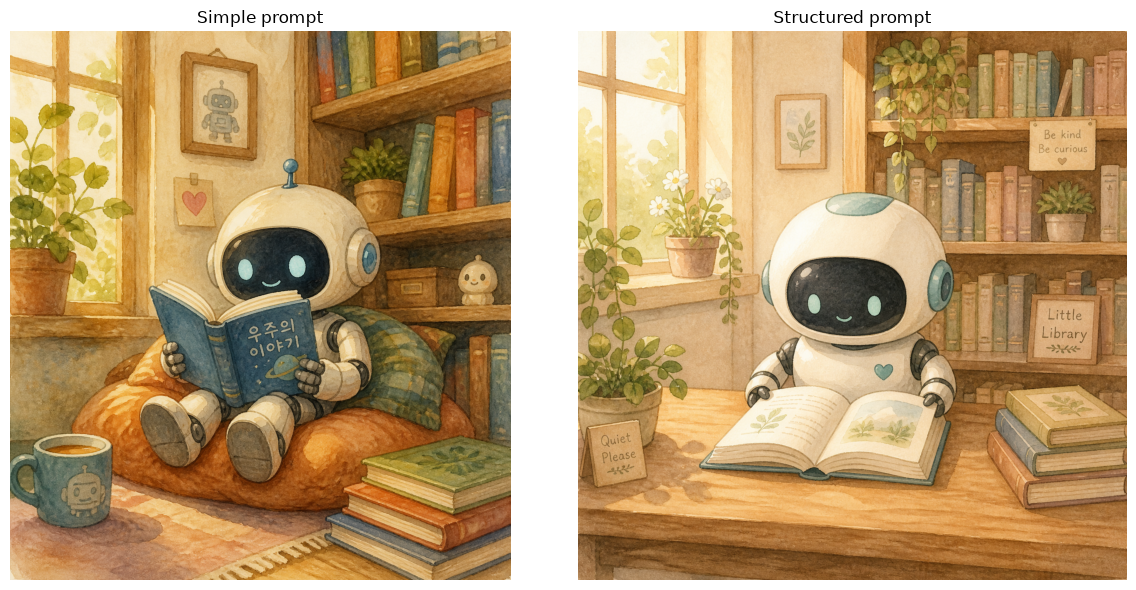

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

comparison_items = [
    (simple_path, "Simple prompt"),
    (structured_path, "Structured prompt"),
]
for axis, (image_path, title) in zip(axes, comparison_items):
    # Image.open()은 저장된 PNG를 읽고 imshow()가 해당 axis에 픽셀을 표시한다.
    with Image.open(image_path) as image:
        axis.imshow(image)
    axis.set_title(title)
    axis.axis("off")

plt.tight_layout()
plt.show()


## 결과 해석과 다음 prompt 개선

구조화 prompt가 항상 더 아름다운 이미지를 보장하는 것은 아니다. 다만 원하는 조건을 항목별로 명시하면 결과가 요구사항을 만족했는지 판단하고, 부족한 조건만 수정해 다음 prompt를 만드는 과정이 쉬워진다.

- **대상과 행동**: 로봇이 한 대이며 실제로 펼친 책을 읽고 있는지 확인한다.
- **구도**: 로봇과 책이 잘리지 않고 정면 중간 거리로 배치됐는지 확인한다.
- **조명과 배경**: 왼쪽의 아침 햇빛과 도서관 요소가 구분되는지 확인한다.
- **표현 방식**: 파스텔 색감과 수채화 질감이 나타나는지 확인한다.
- **이미지 속 문자**: 모델이 요청하지 않은 글자를 추가하거나 철자를 틀릴 수 있으므로 간판·책 표지·교육용 문구는 반드시 사람이 검수한다.

조건이 누락됐다면 전체 prompt를 무작정 길게 만들기보다 해당 항목을 더 명확히 수정한 뒤 다시 생성한다. 재생성할 때마다 별도의 API 비용이 발생한다.

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

simple_file_name = "Autoregressive_simple.png"
structured_file_name = "Autoregressive_structured.png"

simple_prompt = '''
Autoregressive의 개념을 설명하는 심플한 교육용 다이어그램을 생성해줘. 이전에 생성된 토큰(또는 단어/이미지 패치)을 바탕으로 다음 토큰을 순차적으로 예측하는 과정을 화살표 흐름으로 보여주고, 흰색 배경에 깔끔하고 이해하기 쉬운 스타일로 표현해줘.
'''

structured_prompt = '''
주제:
Autoregressive(자기회귀) 방식의 개념 설명 이미지

목적:
학생들이 autoregressive가 무엇인지 한눈에 이해할 수 있도록,
“이전까지 생성된 결과를 바탕으로 다음 요소를 하나씩 예측해 나가는 방식”이라는 핵심을 시각적으로 설명한다.

스타일:
- 심플한 교육용 다이어그램
- 흰색 배경
- 불필요한 장식 없는 깔끔한 구성
- 인포그래픽 느낌보다는 개념 설명용 도식
- 텍스트는 읽기 쉽고 간결하게 배치

구성:
- 왼쪽에서 오른쪽으로 흐르는 구조
- 첫 번째 칸: 시작 토큰 또는 시작 입력
- 그 다음 칸들: 이미 생성된 토큰들
- 마지막 칸: “다음 토큰 예측” 영역
- 각 단계가 화살표로 연결되어 순차 생성 과정을 보여준다

핵심 설명 요소:
- “이전 토큰들 → 다음 토큰 예측” 구조를 강조
- 한 번에 전체를 생성하는 것이 아니라,
  한 단계씩 차례대로 생성하는 방식임을 보여준다
- 현재 시점의 입력은 이전까지의 결과 전체를 참고한다는 점을 표현한다

예시 내용:
- 예시 문장 생성 흐름: "나는" → "학교에" → "간다"
- 또는 추상적인 토큰 박스: Token 1 → Token 2 → Token 3 → Next Token
- 이미지 생성 맥락도 함께 보이고 싶다면,
  “이미지 토큰/패치도 같은 방식으로 순차 생성될 수 있음”을 작은 보조 설명으로 넣는다

이미지 안에 들어갈 짧은 문구:
- 제목: "Autoregressive란?"
- 핵심 문장: "이전까지 생성된 결과를 바탕으로 다음 요소를 하나씩 예측하는 방식"
- 보조 문구: "순차 생성", "Next Token Prediction", "이전 정보 활용"

주의사항:
- 내용이 복잡해 보이지 않도록 구성할 것
- 텍스트 양은 최소화할 것
- 학생이 처음 봐도 이해할 수 있게 직관적으로 표현할 것
- 한글 텍스트가 깨지지 않도록 선명하게 렌더링할 것
'''

# 첫 번째 인자는 API에 보낼 prompt이고, 두 번째 인자는 응답을 저장할 파일명이다.
simple_path = generate_and_save(simple_prompt, simple_file_name)
structured_path = generate_and_save(structured_prompt, structured_file_name)

# 반환된 Path는 실제 저장 위치이자 다음 시각화 셀의 입력이다.
print("간단한 prompt 결과:", simple_path)
print("구조화 prompt 결과:", structured_path)



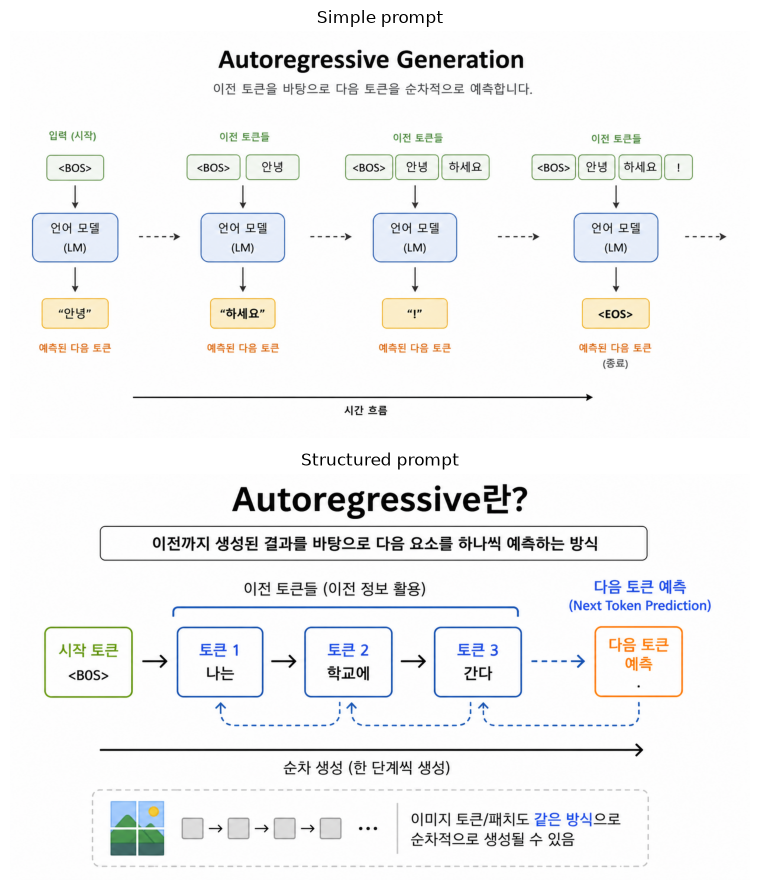

In [9]:

fig, axes = plt.subplots(2, 1, figsize=(18, 9))

comparison_items = [
    (simple_path, "Simple prompt"),
    (structured_path, "Structured prompt"),
]
for axis, (image_path, title) in zip(axes, comparison_items):
    # Image.open()은 저장된 PNG를 읽고 imshow()가 해당 axis에 픽셀을 표시한다.
    with Image.open(image_path) as image:
        axis.imshow(image)
    axis.set_title(title)
    axis.axis("off")

plt.tight_layout()
plt.show()
